In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

In [2]:
ano = 2023

In [3]:
data_dir = Path("data")
INDIR = Path(f"../data/data_model/{ano}")
OUTDIR_IMG = Path(f"../report/img/{ano}")
OUTDIR_IMG.mkdir(parents=True, exist_ok=True)

In [ ]:
arquivo_municipio = INDIR / f"ANALISE_NOTAS_ENEM_MUNICIPIOS_BRASIL_CLUSTERS_{ano}.csv"
df_municipio = pd.read_csv(arquivo_municipio, sep=",")

In [5]:
df_municipio.head()

,MUNICIPIO,UF,QTD_PARTICIPANTES,NOTA_CN_MEDIA,NOTA_CH_MEDIA,NOTA_LC_MEDIA,NOTA_MT_MEDIA,NOTA_REDACAO_MEDIA,MEDIA_GERAL,RENDA_FAMILIAR_SM_MEDIA,CLUSTER
0,ABAETETUBA,PA,4176,468.801628,489.763889,483.747294,475.017002,593.060345,502.078032,0.901661,0
1,ABAETÉ,MG,469,506.850533,536.473561,527.684435,566.819403,634.541578,554.473902,1.898323,2
2,ABREU E LIMA,PE,1737,478.089234,503.526943,502.480311,496.102994,579.090386,511.857974,0.973273,1
3,ACARAPE,CE,386,461.048446,479.891710,485.290155,478.440933,595.544041,500.043057,0.771861,0
4,ACARAÚ,CE,1087,473.678013,497.456026,495.604324,517.502668,684.360626,533.720331,0.756233,1


In [ ]:
dict_municipio = {
    0: df_municipio[df_municipio['CLUSTER'] == 0].copy().reset_index(drop=True),
    1: df_municipio[df_municipio['CLUSTER'] == 1].copy().reset_index(drop=True),
    2: df_municipio[df_municipio['CLUSTER'] == 2].copy().reset_index(drop=True)
}

In [ ]:
colunas_notas = [c for c in df_municipio.columns if c.endswith("_MEDIA")]
cores_cluster = {0: "#ff0e0e", 1: "#1f77b4", 2: "#2ca02c"}

Imagem salva em: ../report/img/2023/2023_DISTRIBUICAO_DAS_MEDIAS_DE_NOTAS_POR_CLUSTER.png


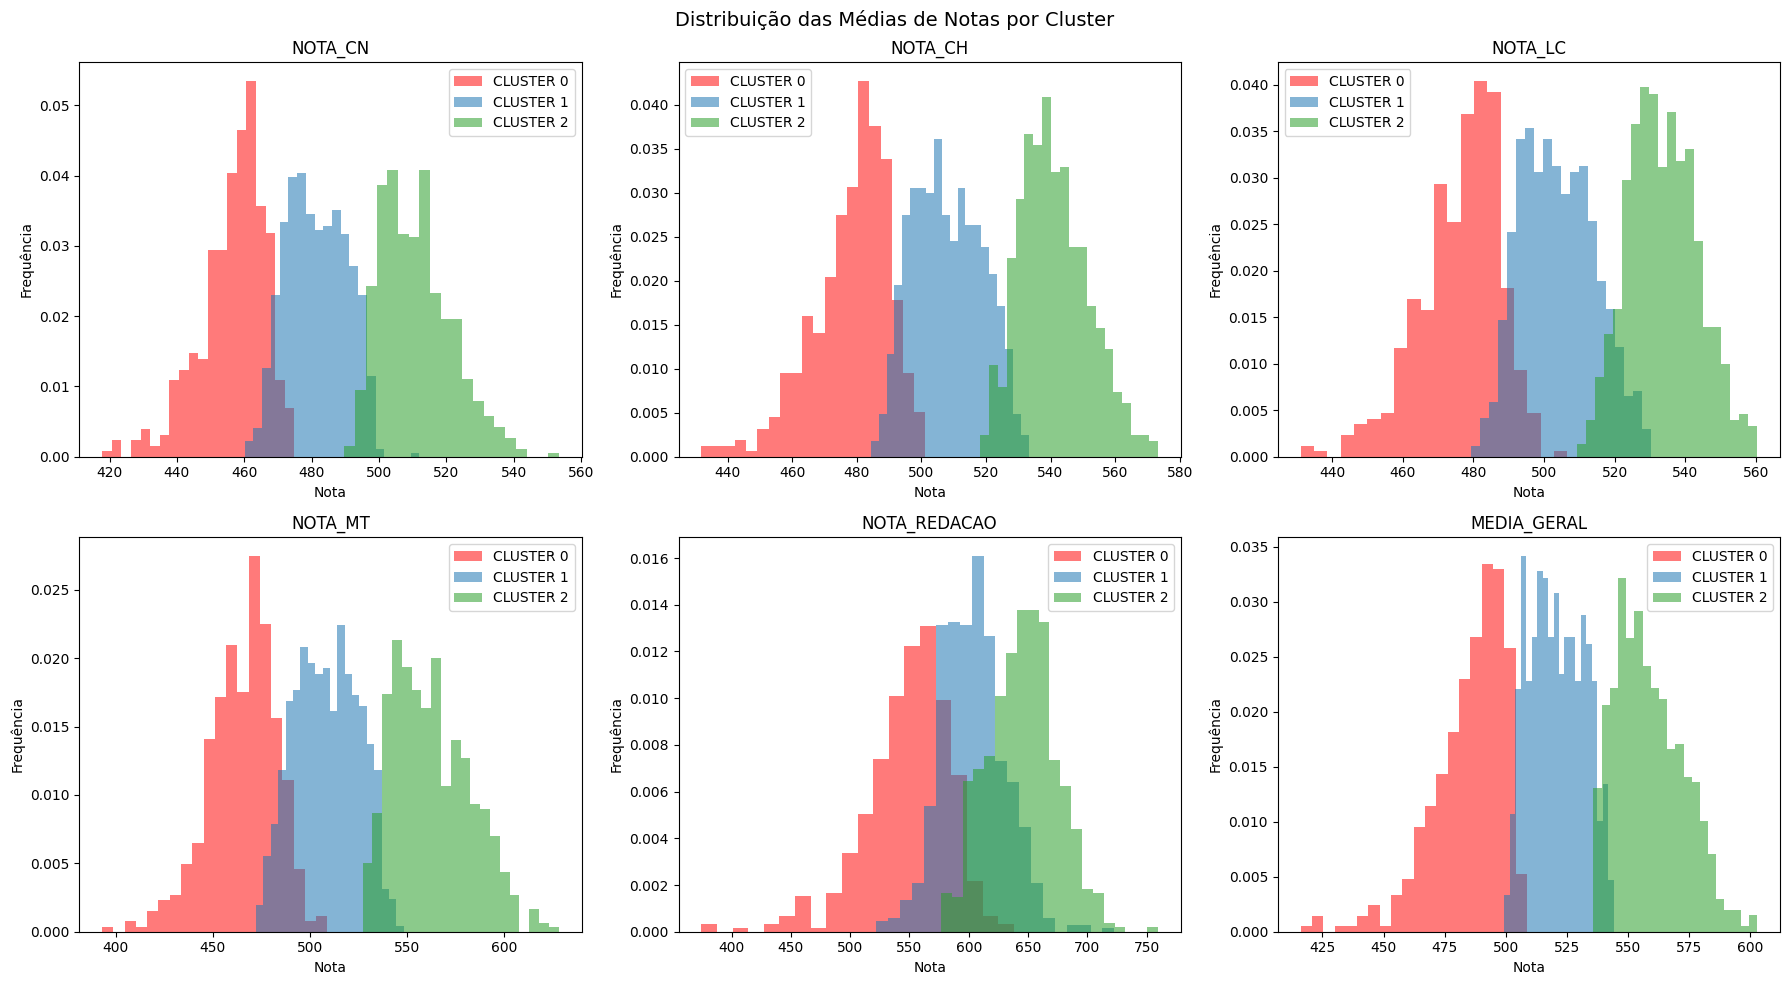

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


coluna_extra = next((c for c in ["MEDIA_GERAL"] if c in df_municipio.columns), None)
if coluna_extra and coluna_extra not in colunas_notas:
    colunas_notas.append(coluna_extra)
for i, coluna in enumerate(colunas_notas):
    ax = axes[i]
    for cluster in sorted(df_municipio["CLUSTER"].unique()):
        ax.hist(
            df_municipio.loc[df_municipio["CLUSTER"] == cluster, coluna],
            bins=20,
            alpha=0.55,
            label=f"CLUSTER {cluster}",
            color=cores_cluster.get(cluster, None),
            density=True
        )
    ax.set_title(coluna.replace("NU_NOTA_", "").replace("_MEDIA", ""))
    ax.set_xlabel("Nota")
    ax.set_ylabel("Frequência")
    ax.legend()

for j in range(len(colunas_notas), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribuição das Médias de Notas por Cluster", fontsize=14)

"""
plt.tight_layout()
caminho = OUTDIR_IMG / f"{ano}_DISTRIBUICAO_DAS_MEDIAS_DE_NOTAS_POR_CLUSTER.png"
fig.savefig(caminho, dpi=300, bbox_inches="tight")
print(f"Imagem salva em: {caminho}")
"""
plt.show()

In [9]:
renda_col = "RENDA_FAMILIAR_SM_MEDIA"

titulos = []
for c in colunas_notas:
    base = c.replace("NOTA_", "").replace("_MEDIA", "")
    d = df_municipio[[renda_col, c]].dropna()
    corr = d[renda_col].corr(d[c])
    titulos.append(f"{base} (r={corr:.3f})")

fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=titulos,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

for i, coluna in enumerate(colunas_notas):
    row = i // 3 + 1
    col = i % 3 + 1

    for cluster in sorted(df_municipio["CLUSTER"].unique()):
        dados = df_municipio[df_municipio["CLUSTER"] == cluster]
        dados_validos = dados[[renda_col, coluna, "MUNICIPIO", "UF", "QTD_PARTICIPANTES"]].dropna()

        fig.add_trace(
            go.Scatter(
                x=dados_validos[renda_col],
                y=dados_validos[coluna],
                mode="markers",
                marker=dict(size=6, color=cores_cluster.get(cluster)),
                opacity=0.7,
                name=f"CLUSTER {cluster}",
                showlegend=(i == 0),
                customdata=dados_validos[["MUNICIPIO", "UF", "QTD_PARTICIPANTES"]],
                hovertemplate=(
                    "Município: %{customdata[0]} (%{customdata[1]})<br>"
                    "Renda: %{x:.2f}<br>"
                    "Nota: %{y:.2f}<br>"
                    "Participantes: %{customdata[2]}<br>"
                    f"Cluster: {cluster}"
                    "<extra></extra>"
                )
            ),
            row=row,
            col=col
        )

    fig.update_xaxes(title_text="Renda Familiar Média (SM)", row=row, col=col)
    fig.update_yaxes(title_text="Nota Média", row=row, col=col)

fig.update_layout(
    title=f"Relação entre Renda Familiar Média e Notas por Cluster (ENEM {ano})",
    height=800,
    width=1200,
    template="plotly_white"
)

"""
caminho = OUTDIR_IMG / f"{ano}_RELACAO_ENTRE_RENDA_FAMILIAR_MEDIA_E_NOTAS_POR_CLUSTER.png"
fig.write_image(str(caminho), scale=2)
print(f"Imagem salva em: {caminho}")
"""
fig.show()
